# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/hands_on/DAY_1_HANDS_ON_SESSION_4_hierarchical_agent_teams.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>





<font color="red" size="10">
<b>HANDS-ON TIME: 15 mins</b>
</font>

# About this Notebook

## From Single Agent to Hierarchical Agent Teams


- the original single-agent baseline
- a **lead agent** that decides when to delegate
- two imported specialist skills loaded from Google Drive
- a consulting report specialist and a frontend implementation specialist
- a final synthesis step that assembles both outputs into one handoff

This example produces a real report and real generated frontend files.

# Visual Overview

## Baseline: single agent

```mermaid
flowchart LR
    U[User Request] --> A[Single Agent]
    A --> T[Search Tool]
    T --> A
    A --> R[Final Response]
```

## Refactor: hierarchical workflow

```mermaid
flowchart LR
    U[User Request] --> L[Lead Agent]
    L --> P{Simple or Complex?}
    P -->|Simple| D[Direct Answer]
    P -->|Complex| C[Consulting Report Specialist]
    C --> F[Frontend Implementation Specialist]
    F --> S[Final Synthesis]
    S --> R[Final Response]
```

The point of the refactor is not that multi-agent is always better. It is that delegation can make larger tasks easier to reason about while keeping specialist outputs explicit.

# Dependencies

In [1]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    openai \
    python-dotenv==1.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 

# API Setup

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("OPENAI_API_KEY not found.")
    OPENAI_API_KEY = input("Enter OPENAI_API_KEY: ").strip()
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("OPENAI_API_KEY is set.")

OPENAI_API_KEY is set.


# Imports

In [3]:
import os
import re
import json
import shutil
import urllib.request
from pathlib import Path
from typing import Annotated, TypedDict

from IPython.display import Code, HTML, Markdown, display
from openai import OpenAI
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, create_react_agent
from langgraph.checkpoint.memory import MemorySaver

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# Part 1: Existing single-agent workflow

The baseline below gives one agent too many responsibilities:

- understand the task
- decide what to research
- run searches
- synthesize the findings
- write the final artifact

That can work for small prompts, but it becomes harder to debug and harder to scale once the request becomes more complex.

In [4]:
def _obj_get(x, key, default=None):
    if isinstance(x, dict):
        return x.get(key, default)
    return getattr(x, key, default)


@tool("internet_search")
def internet_search(query: str) -> dict:
    """Run OpenAI web search and return a compact answer with sources."""
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

    response = client.responses.create(
        model="gpt-5",
        tools=[{"type": "web_search"}],
        include=["web_search_call.action.sources"],
        input=query,
    )

    output_text = _obj_get(response, "output_text", "") or ""
    sources = []

    for item in _obj_get(response, "output", []) or []:
        if _obj_get(item, "type") == "web_search_call":
            action = _obj_get(item, "action")
            for src in _obj_get(action, "sources", []) or []:
                sources.append(
                    {
                        "title": _obj_get(src, "title"),
                        "url": _obj_get(src, "url"),
                    }
                )

    return {
        "query": query,
        "answer": output_text,
        "sources": sources,
    }


class SingleAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


single_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0).bind_tools([internet_search])

SINGLE_AGENT_SYSTEM = """
You are one agent responsible for the full task.

You may use the `internet_search` tool when helpful.
You must handle planning, research, synthesis, and writing yourself.
Try to produce a concise but useful answer with source URLs when available.
""".strip()


def single_agent_node(state: SingleAgentState) -> SingleAgentState:
    msgs = [SystemMessage(content=SINGLE_AGENT_SYSTEM), *state["messages"]]
    ai = single_llm.invoke(msgs)
    return {"messages": [ai]}


def route_after_single_agent(state: SingleAgentState):
    last = state["messages"][-1]
    calls = getattr(last, "tool_calls", None) or []
    return "tools" if calls else END


single_agent_graph = StateGraph(SingleAgentState)
single_agent_graph.add_node("agent", single_agent_node)
single_agent_graph.add_node("tools", ToolNode([internet_search]))
single_agent_graph.add_edge(START, "agent")
single_agent_graph.add_conditional_edges(
    "agent",
    route_after_single_agent,
    {"tools": "tools", END: END},
)
single_agent_graph.add_edge("tools", "agent")

single_agent_app = single_agent_graph.compile(checkpointer=MemorySaver())

In [5]:
single_agent_prompt = """
Create a short strategy brief for launching an AI study assistant.

You need to:
1. Identify recent market signals or competitor moves.
2. Summarize the main user pain points.
3. Recommend a positioning angle.
4. Draft a short executive summary.

Keep the final answer structured and include source URLs.
""".strip()

single_config = {
    "configurable": {"thread_id": "single-agent-baseline"},
    "recursion_limit": 8,
}

single_result = single_agent_app.invoke(
    {"messages": [HumanMessage(content=single_agent_prompt)]},
    config=single_config,
)

print(single_result["messages"][-1].content)

## Strategy brief: Launching an AI study assistant

### 1) Recent market signals / competitor moves
- **OpenAI moved from “answer engine” to guided learning** with ChatGPT **Study mode** (July 2025), explicitly coaching students step-by-step instead of just solving for them.  
  Source: https://openai.com/index/chatgpt-study-mode/
- **Google is building a full education stack**: Gemini in Workspace for Education, **NotebookLM** for source-grounded study help, and **Guided Learning** in Gemini to push understanding over instant answers.  
  Sources:  
  https://workspaceupdates.googleblog.com/2024/05/Gemini-for-Google-Workspace-For-Education.html  
  https://edu.google.com/ai-notebooklm/  
  https://blog.google/products-and-platforms/products/education/guided-learning/
- **Khan Academy/Khanmigo is positioning AI as a tutor and teacher aid**, with district-led rollout and paid learner access.  
  Sources:  
  https://support.khanacademy.org/hc/en-us/articles/14799155077261-Can-I-give-my-

# Part 2: Multi-agent

This version uses a more defined path instead of fully dynamic delegation:

- the **lead agent** decides whether to answer directly or use the specialist path
- a **consulting report specialist** loads its skill from Google Drive and writes a real report
- a **frontend implementation specialist** loads its skill from Google Drive and creates real files
- a final **synthesizer** combines both into one response

Important design choice:

- the frontend specialist does **not** build the page directly from the consulting report structure
- instead, it receives a compact product/UX handoff plus separate learning-platform landing-page research
- only selected insights, such as pain points and trust requirements, flow across

This keeps the two tasks related but still distinct.

# Single Agent vs Multi-Agent

## Single agent strengths

- simpler to build
- fewer moving parts
- good for short or well-bounded tasks

## Single agent weaknesses

- one prompt has to juggle planning, research, reasoning, and writing
- harder to inspect where quality breaks down
- harder to scale when tasks become broader or more open-ended

## Multi-agent strengths

- the lead agent can stay focused on coordination
- specialists can use narrower prompts and clearer responsibilities
- delegation makes complex tasks easier to debug and extend

## Multi-agent tradeoffs

- more orchestration code
- more model calls
- more design choices around routing, limits, and shared context

A useful rule of thumb: start with one agent, then split responsibilities only when the task complexity justifies it.

In [6]:
class LeadDecision(BaseModel):
    is_complex: bool = Field(
        ..., description="Whether the request needs the specialist pipeline."
    )
    direct_answer: str = Field(
        default="", description="Used only if the request is simple enough to answer directly."
    )
    reason: str = Field(
        default="", description="Short explanation for the routing choice."
    )


class SearchQueries(BaseModel):
    queries: list[str] = Field(
        default_factory=list,
        description="One to three focused web-search queries.",
    )


class FrontendHandoff(BaseModel):
    product_name: str = Field(..., description="Product or brand name to use on the landing page.")
    target_audience: str = Field(..., description="Primary audience for the learning platform.")
    core_value_proposition: str = Field(..., description="Short value proposition for the product.")
    top_pain_points: list[str] = Field(default_factory=list, description="Top user pain points relevant to product UX.")
    trust_requirements: list[str] = Field(default_factory=list, description="Trust-building requirements the UI should communicate.")
    primary_cta: str = Field(..., description="Main call to action for the landing page.")
    secondary_cta: str = Field(default="", description="Optional secondary CTA.")
    ux_notes: list[str] = Field(default_factory=list, description="Landing page UX notes, not report sections.")


class MultiAgentState(TypedDict, total=False):
    messages: Annotated[list[BaseMessage], add_messages]
    request: str
    consulting_report: str
    frontend_handoff: str
    frontend_research: str
    frontend_summary: str
    frontend_files: list[str]
    final_answer: str

In [7]:
CONSULTING_SKILL_URL = "https://drive.google.com/file/d/1SoYAFow_pF27LpywXZ410-PwoiYf4x-G/view?usp=sharing"
FRONTEND_SKILL_URL = "https://drive.google.com/file/d/1PwGnA-u1l_gs7dFiyclSWwmaf0MRxEPh/view?usp=sharing"


def extract_drive_file_id(url: str) -> str:
    match = re.search(r"/d/([^/]+)", url)
    if not match:
        raise ValueError(f"Could not extract Google Drive file id from: {url}")
    return match.group(1)


def load_drive_markdown(url: str) -> str:
    file_id = extract_drive_file_id(url)
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
    with urllib.request.urlopen(download_url) as response:
        text = response.read().decode("utf-8")
    if "<html" in text[:500].lower() or "sign in" in text[:500].lower():
        raise ValueError("Google Drive returned HTML instead of raw Markdown. Make sure the file is shared for download.")
    return text


CONSULTING_SKILL = load_drive_markdown(CONSULTING_SKILL_URL)
FRONTEND_SKILL = load_drive_markdown(FRONTEND_SKILL_URL)

print("Loaded consulting skill characters:", len(CONSULTING_SKILL))
print("Loaded frontend skill characters:", len(FRONTEND_SKILL))

WORKING_DIRECTORY = Path("generated_frontend")
WORKING_DIRECTORY.mkdir(exist_ok=True)

repl = PythonREPL()


def log_step(message: str) -> None:
    print(message, flush=True)


def preview_text(text, limit: int = 160) -> str:
    if not isinstance(text, str):
        text = str(text)
    one_line = " ".join(text.split())
    return one_line[:limit] + ("..." if len(one_line) > limit else "")


def print_agent_event(prefix: str, event: dict) -> None:
    for node_name, payload in event.items():
        messages = payload.get("messages", []) if isinstance(payload, dict) else []
        if not messages:
            log_step(f"[{prefix}:{node_name}] update received")
            continue
        last = messages[-1]
        tool_calls = getattr(last, "tool_calls", None) or []
        if tool_calls:
            names = ", ".join(call.get("name", "tool") for call in tool_calls)
            log_step(f"[{prefix}:{node_name}] tool calls -> {names}")
            continue
        content = getattr(last, "content", "")
        if content:
            log_step(f"[{prefix}:{node_name}] {preview_text(content)}")

@tool("write_project_file")
def write_project_file(path: str, content: str) -> str:
    """Write a file inside the generated_frontend working directory."""
    full_path = WORKING_DIRECTORY / path
    full_path.parent.mkdir(parents=True, exist_ok=True)
    full_path.write_text(content, encoding="utf-8")
    return f"Wrote {full_path}"


@tool("read_project_file")
def read_project_file(path: str) -> str:
    """Read a file from the generated_frontend working directory."""
    full_path = WORKING_DIRECTORY / path
    return full_path.read_text(encoding="utf-8")


@tool("list_project_files")
def list_project_files() -> list[str]:
    """List files inside the generated_frontend working directory."""
    return sorted(
        str(path.relative_to(WORKING_DIRECTORY))
        for path in WORKING_DIRECTORY.rglob("*")
        if path.is_file()
    )


@tool("python_repl_tool")
def python_repl_tool(code: str) -> str:
    """Execute Python code for local project setup, validation, or file inspection."""
    try:
        output = repl.run(code)
    except BaseException as exc:
        return f"Python REPL failed: {exc!r}"
    return output or "Python REPL executed successfully."


lead_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
query_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
report_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
lead_router = lead_llm.with_structured_output(LeadDecision)
frontend_handoff_llm = report_llm.with_structured_output(FrontendHandoff)

frontend_agent = create_react_agent(
    ChatOpenAI(model="gpt-5.4-mini", temperature=0),
    tools=[write_project_file, read_project_file, list_project_files, python_repl_tool],
    prompt=(
        FRONTEND_SKILL
        + "\n\nYou are the frontend implementation specialist inside a hierarchical workflow. "
        + "Create a simple, polished landing page for a learning platform. "
        + "Do not turn consulting-report sections into website sections. "
        + "Use only the frontend handoff and learning-platform UX research provided to you. "
        + "Focus on conversion, clarity, trust, and product UX for a student-facing learning platform. "
        + "You must create `index.html` and may also create `styles.css` and `app.js`. "
        + "Use the tools to write files, verify the file list, and finish with a concise summary of what you created."
    ),
)

LEAD_SYSTEM = """
You are a lead agent.

If the request is simple, answer directly.
If the request is complex, route it into this fixed pipeline:
1. consulting report specialist
2. frontend implementation specialist
3. final synthesizer
""".strip()


def extract_json_object(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        parts = text.split("```")
        if len(parts) >= 3:
            text = parts[1]
            if text.startswith("json"):
                text = text[4:]
            text = text.strip()

    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1 or end <= start:
        raise ValueError(f"Could not extract JSON object from: {preview_text(text, 300)}")
    return text[start : end + 1]


def plan_search_queries(system_instruction: str, user_content: str, max_queries: int) -> SearchQueries:
    response = query_llm.invoke(
        [
            SystemMessage(
                content=(
                    system_instruction
                    + " Return ONLY valid JSON matching this schema: "
                    + '{"queries": ["query 1", "query 2"]}'
                    + ". No prose, no markdown fences, no explanation."
                )
            ),
            HumanMessage(content=user_content),
        ]
    )

    raw = response.content if hasattr(response, "content") else str(response)
    try:
        parsed = SearchQueries.model_validate_json(raw)
    except Exception:
        parsed = SearchQueries.model_validate_json(extract_json_object(raw))

    cleaned = [query.strip() for query in parsed.queries if isinstance(query, str) and query.strip()]
    if not cleaned:
        raise ValueError(f"Query planner returned no usable queries: {preview_text(raw, 300)}")
    return SearchQueries(queries=cleaned[:max_queries])


def build_search_context(request: str) -> str:
    log_step("[consulting] planning search queries")
    query_plan = plan_search_queries(
        system_instruction=(
            "Generate one to three focused web-search queries that help a consulting specialist "
            "write a consulting-grade launch report with market signals, competitors, and user pain points."
        ),
        user_content=request,
        max_queries=3,
    )

    findings = []
    for index, query in enumerate(query_plan.queries[:3], start=1):
        log_step(f"[consulting] search {index}: {query}")
        result = internet_search.invoke({"query": query})
        findings.append(result)
        log_step(f"[consulting] search {index} complete")

    return json.dumps(findings, indent=2)


def build_frontend_research_context(request: str, frontend_handoff: FrontendHandoff) -> str:
    log_step("[frontend] planning UX research queries")
    query_plan = plan_search_queries(
        system_instruction=(
            "Generate one or two focused web-search queries about good landing-page UI/UX for learning platforms, "
            "student-facing edtech products, onboarding clarity, trust signals, and conversion best practices."
        ),
        user_content=(
            f"Request: {request}\n"
            f"Product: {frontend_handoff.product_name}\n"
            f"Audience: {frontend_handoff.target_audience}\n"
            f"Value proposition: {frontend_handoff.core_value_proposition}"
        ),
        max_queries=2,
    )

    findings = []
    for index, query in enumerate(query_plan.queries[:2], start=1):
        log_step(f"[frontend] UX search {index}: {query}")
        result = internet_search.invoke({"query": query})
        findings.append(result)
        log_step(f"[frontend] UX search {index} complete")

    return json.dumps(findings, indent=2)


def build_frontend_handoff(consulting_report: str) -> FrontendHandoff:
    log_step("[frontend] extracting product and UX handoff from consulting report")
    return frontend_handoff_llm.invoke(
        [
            SystemMessage(
                content=(
                    "Extract only the minimum product strategy inputs that a frontend designer should use. "
                    "Do not preserve the report structure. Focus on audience, value proposition, pain points, trust signals, CTAs, and UX notes."
                )
            ),
            HumanMessage(content=consulting_report),
        ]
    )

Loaded consulting skill characters: 33333
Loaded frontend skill characters: 7660


In [8]:
SYNTHESIZER_SYSTEM = """
You are the final synthesizer in a hierarchical agent workflow.
Combine the consulting report and the frontend implementation outcome into one concise handoff.
Preserve source URLs when they are available.
Highlight what was researched, what was built, and what to do next.
""".strip()


def lead_agent_node(state: MultiAgentState) -> MultiAgentState:
    request = state.get("request") or state["messages"][-1].content
    log_step("[lead] deciding whether to use specialist pipeline")

    decision = lead_router.invoke(
        [
            SystemMessage(content=LEAD_SYSTEM),
            HumanMessage(content=request),
        ]
    )
    log_step(f"[lead] is_complex={decision.is_complex} reason={preview_text(decision.reason)}")

    if not decision.is_complex:
        return {
            "request": request,
            "final_answer": decision.direct_answer or "This request looks simple enough to answer directly.",
        }

    return {"request": request}


def consulting_specialist_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[consulting] starting consulting report generation")
    search_context = build_search_context(state["request"])
    log_step("[consulting] drafting consulting report")

    prompt = f"""
Research request:
{state['request']}

External search findings:
{search_context}

Using the imported consulting skill, write a substantial consulting-grade Markdown report.
The report must include these sections:
1. Executive Summary
2. Market Signals and Competitor Moves
3. User Pain Points
4. Positioning Recommendation
5. Product and Launch Implications
6. References

Requirements:
- Use only evidence from the provided search findings.
- Preserve source URLs in the report.
- Be specific and strategic rather than generic.
""".strip()

    result = report_llm.invoke(
        [
            SystemMessage(content=CONSULTING_SKILL),
            HumanMessage(content=prompt),
        ]
    )
    log_step("[consulting] report complete")
    return {"consulting_report": result.content}


def frontend_specialist_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[frontend] preparing working directory")
    if WORKING_DIRECTORY.exists():
        shutil.rmtree(WORKING_DIRECTORY)
    WORKING_DIRECTORY.mkdir(exist_ok=True)

    frontend_handoff = build_frontend_handoff(state["consulting_report"])
    frontend_research = build_frontend_research_context(state["request"], frontend_handoff)

    prompt = f"""
Build a simple, polished landing page for a learning platform.

Original request:
{state['request']}

Frontend handoff:
{frontend_handoff.model_dump_json(indent=2)}

Learning-platform landing-page UX research:
{frontend_research}

Requirements:
- Do not mirror the consulting report structure as webpage sections.
- Use the pain points only as product insight, not as a report-style content layout.
- The page should feel like a clear, student-facing learning platform landing page, with dark/light contrasts for font and background.
- Prioritize hero clarity, trust signals, product workflow, social proof or credibility, and conversion.
- Create a real frontend implementation in the working directory.
- You must create `index.html`.
- You should also create `styles.css` and optionally `app.js`.
- Keep everything local with no build step.
- After writing files, verify the file list and finish with a short build summary.
""".strip()

    log_step("[frontend] starting tool-using frontend agent")
    final_state = None
    for event in frontend_agent.stream(
        {"messages": [HumanMessage(content=prompt)]},
        config={"recursion_limit": 8},
        stream_mode="values",
    ):
        final_state = event
        messages = event.get("messages", []) if isinstance(event, dict) else []
        if messages:
            last = messages[-1]
            tool_calls = getattr(last, "tool_calls", None) or []
            if tool_calls:
                names = ", ".join(call.get("name", "tool") for call in tool_calls)
                log_step(f"[frontend] tool calls -> {names}")
            else:
                content = getattr(last, "content", "")
                if content:
                    log_step(f"[frontend] {preview_text(content)}")

    files = list_project_files.invoke({})
    summary = final_state.get("messages", [])[-1].content if final_state and final_state.get("messages") else ""
    log_step(f"[frontend] files created: {', '.join(files) if files else 'none'}")
    return {
        "frontend_handoff": frontend_handoff.model_dump_json(indent=2),
        "frontend_research": frontend_research,
        "frontend_summary": summary,
        "frontend_files": files,
    }


def synthesizer_node(state: MultiAgentState) -> MultiAgentState:
    log_step("[synthesizer] preparing final handoff")
    prompt = f"""
Original request:
{state['request']}

Consulting report:
{state['consulting_report']}

Frontend handoff:
{state.get('frontend_handoff', '')}

Frontend implementation summary:
{state['frontend_summary']}

Created frontend files:
{json.dumps(state.get('frontend_files', []), indent=2)}

Write a short final handoff with these sections:
1. What the consulting specialist delivered
2. What the frontend specialist built
3. Why the frontend task was intentionally separated from the report structure
4. Recommended next steps
""".strip()

    final = report_llm.invoke(
        [
            SystemMessage(content=SYNTHESIZER_SYSTEM),
            HumanMessage(content=prompt),
        ]
    )

    log_step("[synthesizer] final handoff ready")
    return {"final_answer": final.content}


def route_after_lead(state: MultiAgentState):
    return END if state.get("final_answer") else "consulting_specialist"


multi_agent_graph = StateGraph(MultiAgentState)
multi_agent_graph.add_node("lead", lead_agent_node)
multi_agent_graph.add_node("consulting_specialist", consulting_specialist_node)
multi_agent_graph.add_node("frontend_specialist", frontend_specialist_node)
multi_agent_graph.add_node("synthesizer", synthesizer_node)

# TODO add a lead agent as an edge
multi_agent_graph.add_edge(START, "lead")

multi_agent_graph.add_conditional_edges(
    "lead",
    route_after_lead,
    {"consulting_specialist": "consulting_specialist", END: END},
)
multi_agent_graph.add_edge("consulting_specialist", "frontend_specialist")
multi_agent_graph.add_edge("frontend_specialist", "synthesizer")
multi_agent_graph.add_edge("synthesizer", END)

multi_agent_app = multi_agent_graph.compile(checkpointer=MemorySaver())

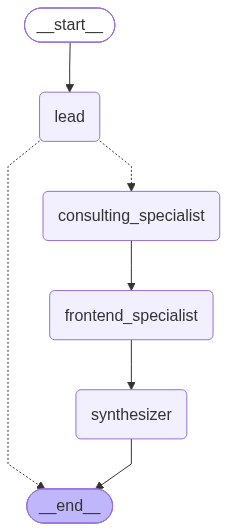

In [9]:
from IPython.display import Image, display

display(Image(multi_agent_app.get_graph().draw_mermaid_png()))

# Run with live progress

The cell below uses `multi_agent_app.stream(...)` instead of `invoke(...)`.

That means you should now see live updates while the graph runs:

- lead-agent routing
- consulting search and report generation
- frontend tool calls and file creation
- final synthesis

In [10]:
multi_agent_prompt = """
Create a consulting-grade launch recommendation for an AI study assistant.

You need to:
1. Research recent market signals or competitor moves.
2. Summarize the main user pain points.
3. Recommend a positioning angle.
4. Build a simple landing page for a learning platform, not a webpage version of the consulting report.
5. Use only the relevant strategic handoff from the report plus separate learning-platform UX guidance.
6. Produce both the consulting report and the frontend implementation.
""".strip()


def run_multi_agent_with_stream(prompt: str, thread_id: str = "multi-agent-hands-on-solution"):
    config = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": 6,
    }

    log_step("[run] starting graph stream")
    for event in multi_agent_app.stream(
        {
            "messages": [HumanMessage(content=prompt)],
            "request": prompt,
        },
        config=config,
        stream_mode="updates",
    ):
        print_agent_event("graph", event)

    final_state = multi_agent_app.get_state(config).values
    log_step("[run] graph complete")
    return final_state


multi_result = run_multi_agent_with_stream(multi_agent_prompt)

print(multi_result["final_answer"])

display(Markdown(multi_result["consulting_report"]))

for file_name in multi_result.get("frontend_files", []):
    language = "html"
    if file_name.endswith(".css"):
        language = "css"
    elif file_name.endswith(".js"):
        language = "javascript"
    display(Code(read_project_file.invoke({"path": file_name}), language=language))

[run] starting graph stream
[lead] deciding whether to use specialist pipeline
[lead] is_complex=True reason=The request requires research, strategy, and a separate frontend deliverable, so it should be routed through the consulting report specialist, frontend implemen...
[graph:lead] update received
[consulting] starting consulting report generation
[consulting] planning search queries
[consulting] search 1: AI study assistant market signals competitor moves 2024 2025 Notion Quizlet Khan Academy Duolingo study tools launch
[consulting] search 1 complete
[consulting] search 2: student learning platform pain points AI study assistant user research academic anxiety note taking quiz generation retention
[consulting] search 2 complete
[consulting] search 3: landing page best practices learning platform UX conversion social proof clear value proposition education SaaS
[consulting] search 3 complete
[consulting] drafting consulting report
[consulting] report complete
[graph:consulting_specia

# AI Study Assistant Launch Recommendation

## Executive Summary

The AI study-assistant market is moving away from generic “chat with your docs” positioning and toward **workflow-embedded, source-grounded, and outcome-specific learning experiences**. Recent competitor moves show a clear pattern: Notion is turning notes and files into a unified study knowledge base; Quizlet is expanding from flashcards into structured exam-prep workflows while retreating from always-on chat tutoring; Khan Academy is doubling down on teacher-first distribution inside LMS environments; and Duolingo is pushing toward multimodal, real-time practice experiences. Together, these signals suggest the category is no longer won by “AI answers” alone, but by **where the assistant lives, what it is grounded on, and which learning job it completes end to end**. [Notion releases](https://www.notion.com/releases/2024-09-25), [Quizlet PR](https://www.prnewswire.com/news-releases/quizlet-unveils-enhanced-and-new-digital-tools-to-power-effective-and-efficient-student-learning-302214650.html), [Khan Academy/Microsoft](https://www.microsoft.com/en-us/education/blog/2024/05/enhancing-the-future-of-education-with-khan-academy/), [Duolingo investor release](https://investors.duolingo.com/news-releases/news-release-details/duolingo-introduces-ai-powered-innovations-duocon-2024)

The strongest user pain points are also consistent across the evidence: students struggle with fragmented materials, passive studying, weak note-taking, poor readiness calibration, time pressure, low trust in AI answers, and retention drop-off. The strategic implication is straightforward: the winning product should not position itself as a general tutor. It should instead promise to **turn scattered class materials into a trusted study system that helps students know what to study, practice it effectively, and feel more prepared**. This is the clearest wedge against both generic AI copilots and broad study platforms.

For launch, the recommended positioning is: **“Your grounded study system for notes, quizzes, and exam readiness.”** This angle is defensible because it addresses the core tension in the market: students want the convenience of AI, but they do not trust open-ended AI enough for high-stakes learning. A product that is source-anchored, syllabus-aware, and structured around retrieval practice can reduce that trust gap while avoiding the cost and safety burden of always-on freeform tutoring.

For the landing page, the UX should be built as a **conversion-focused learning-platform page**, not a consulting report page. The page should lead with one primary promise, one primary CTA, visible social proof, and a simple three-step product story: import materials, generate structured study assets, and practice with confidence. The page should avoid overexplaining AI and instead show a concrete learner outcome.

## 1. Market Signals and Competitor Moves

The current market is best understood as a set of converging strategic moves rather than isolated product updates.

### 1.1 Notion: from note-taking app to personal study knowledge base

Notion’s 2024 updates show a clear shift toward unified, source-grounded knowledge retrieval. On September 25, 2024, Notion AI added unified Q&A across external sources such as Slack and Google Drive/Slides, alongside style-guided generation via @-mentions. On June 18, 2024, release notes highlighted GPT-4-powered chat and summarization inside pages. Notion’s own Q&A guidance explicitly frames student use cases such as building study plans and synthesizing notes. [Notion release 2024-09-25](https://www.notion.com/releases/2024-09-25), [Notion release 2024-06-18](https://www.notion.com/releases/2024-06-18), [Notion Q&A guide](https://www.notion.com/en-gb/help/guides/unearth-fresh-insights-from-your-personal-knowledge-library-using-q-and-a)

This matters because Notion is not competing as a “study app” in the traditional sense; it is expanding the definition of where study begins. The signal is that users increasingly want to ask questions against their own notes, files, and school materials rather than the open web. That implies a strong demand for **personal knowledge organization plus AI retrieval**.

### 1.2 Quizlet: from flashcards to structured exam prep, with a retreat from always-on chat

Quizlet’s August 2024 back-to-school updates introduced AI-assisted Practice Tests and Study Guides generated from uploaded class notes, plus classroom games. That is a meaningful expansion beyond flashcards into broader exam-prep workflows. But the more important signal is its June 30, 2025 discontinuation of Q-Chat, which indicates a retreat from open-ended student-facing tutoring toward more structured study formats. Quizlet appears to be prioritizing generation and testing over always-on conversational tutoring. [Quizlet PR](https://www.prnewswire.com/news-releases/quizlet-unveils-enhanced-and-new-digital-tools-to-power-effective-and-efficient-student-learning-302214650.html), [Quizlet Q-Chat help](https://help.quizlet.com/hc/zh-cn/articles/18811152410125-%E5%88%A9%E7%94%A8Q-Chat%E5%AD%A6%E4%B9%A0)

Strategically, this suggests two things. First, students still want AI-assisted practice. Second, the economics and trust burden of always-on tutoring are hard to sustain at scale. The market may reward products that help students **prepare better**, rather than products that try to replace a human tutor in every scenario.

### 1.3 Khan Academy: distribution is moving into teacher workflows and LMS environments

Khan Academy’s 2024 moves are especially relevant for distribution strategy. On May 21–22, 2024, Khan Academy made Khanmigo for Teachers free for all U.S. educators with Microsoft support. On September 30, 2024, Khanmigo teacher tools were integrated into Canvas LMS. The overall pattern is teacher-first and workflow-embedded, not consumer-chat-first. [Microsoft blog](https://www.microsoft.com/en-us/education/blog/2024/05/enhancing-the-future-of-education-with-khan-academy/), [Khan Academy blog](https://blog.khanacademy.org/ai-teaching-assistant-khanmigo-now-available-in-canvas-trusted-ai-to-streamline-prep-right-inside-your-lms/)

The strategic message is that education products win faster when they meet users where they already work. In this case, the “user” is not just the student; it is also the teacher or institution. For a new AI study assistant, this is a warning against over-relying on a standalone consumer acquisition model.

### 1.4 Duolingo: premium AI learning is moving toward multimodal practice

Duolingo’s September 24, 2024 Duocon launch introduced AI Video Call with Lily for real-time conversational practice and Adventures for scenario-based practice. In 2025, Duolingo continued expanding this feature set. The direction is clear: premium learning experiences are becoming more immersive, interactive, and simulation-like. [Duolingo release](https://investors.duolingo.com/news-releases/news-release-details/duolingo-introduces-ai-powered-innovations-duocon-2024), [Duolingo 2025 PDF](https://investors.duolingo.com/node/11316/pdf)

This matters less as a direct student-study competitor and more as a category signal. Users are increasingly willing to pay for AI experiences that feel active, adaptive, and personalized. However, Duolingo’s success also depends on a tightly scoped domain. It is not an open-ended study assistant; it is a language-learning system with clear progression mechanics.

### 1.5 Market synthesis

Across all four players, the market is moving along four dimensions:

1. **From generic chat to grounded answers**
2. **From standalone apps to embedded workflows**
3. **From always-on tutoring to structured study flows**
4. **From text-only interactions to more immersive, multimodal practice**

The opportunity for a new entrant is therefore not “another AI tutor.” It is a **trusted study operating system** that combines note structuring, quiz generation, and exam readiness in a product flow students can actually sustain.

## 2. User Pain Points

The research findings point to a very coherent set of student pain points. The key advantage of this evidence is that it is not abstract; it maps directly to specific failure points in the study journey.

### 2.1 Fragmented materials

Students often have slides, PDFs, lecture audio, and personal notes spread across different places. This makes it hard to consolidate, search, and revisit what matters. In practice, fragmentation breaks the study loop before it starts: if students cannot quickly find the source material, they default to inefficient rereading or last-minute cramming.

### 2.2 Passive study habits

The findings show that rereading and highlighting create the illusion of productivity but do not support strong recall. The absence of retrieval practice is a central weakness. Students may feel busy, but they are not testing memory or identifying gaps. This is one of the most important product opportunities because it defines a clear behavioral intervention: the assistant should move users from passive consumption to active recall.

### 2.3 Ineffective note-taking

Students struggle to keep up during lectures, miss context, and often cannot capture formulas or diagrams cleanly. This is especially acute in STEM courses, but it applies more broadly whenever pace and structure matter. The pain point is not simply “bad notes”; it is that notes fail to become usable study assets afterward.

### 2.4 Poor readiness calibration and academic anxiety

A recurring issue is that students misjudge whether they are actually prepared. That disconnect creates anxiety right before exams. The product implication is that students need more than help studying; they need help **knowing what they know**. A study assistant that can surface weak areas, generate practice, and show readiness more visibly can address both performance and anxiety.

### 2.5 Time pressure and planning friction

Students often do not know what to study, when to study, or for how long. This creates procrastination and inefficient cram sessions. The pain is not lack of intent; it is lack of structure. Therefore, time-boxed study plans and micro-sessions are likely to be highly attractive.

### 2.6 Low trust in AI

Students fear hallucinations, incorrect steps in STEM, or outdated sources. This is a critical blocker. It means an AI study assistant must earn trust through grounding, citations, and explicit confidence signals. If the assistant cannot show where an answer comes from, it will struggle in high-stakes learning moments.

### 2.7 Accessibility gaps

The findings mention ESL, dyslexia, ADHD, and limited multimodal support. Dense text is a barrier. Students need simplification, audio support, and better structure without losing accuracy. This is not a side feature; it is part of product-market fit for a broad student audience.

### 2.8 Quiz quality and retention drop-off

Auto-generated questions are often too easy or too hard, with weak distractors and poor alignment to the syllabus. Users also lack spaced repetition and interleaving across topics, which creates retention drop-off. The product opportunity is to make practice **relevant, calibrated, and repeated**.

### 2.9 Integrity and privacy concerns

Students worry about honor code violations, privacy, and data use. That means the product must be explicit about assessment mode, data controls, and privacy posture. In education, trust is not only a UX issue; it is a buying criterion.

## 3. Positioning Recommendation

### Recommended positioning angle

**Position the product as: “Your grounded study system for notes, quizzes, and exam readiness.”**

This positioning is stronger than “AI tutor,” “AI note taker,” or “study chatbot” because it combines three things the market evidence says are essential:

- **Grounded**: answers come from the student’s materials, not generic web output
- **Study system**: the product supports a workflow, not just a query box
- **Exam readiness**: the promise is outcome-based, not feature-based

### Why this angle is the right wedge

#### 3.1 It matches the market shift toward source-grounded assistants
Notion’s move into cross-source Q&A and student study use cases shows that users want a personal knowledge base they can interrogate. Your product should go further by specializing in study materials and classroom context. That makes the promise more concrete and more valuable.

#### 3.2 It avoids the always-on tutoring trap
Quizlet’s discontinuation of Q-Chat is a strong signal that freeform student tutoring is hard to sustain. A product built around structured study flows, quizzes, and readiness checks is more likely to be economically and operationally durable.

#### 3.3 It aligns with the core student anxiety
The deepest emotional pain is not just “I have too much to study.” It is “I do not know if I am ready.” A product that helps students turn scattered content into a visible readiness system directly addresses that tension.

### Positioning statement

**For students who need to turn messy class materials into effective study sessions, our AI study assistant converts notes, slides, and PDFs into structured summaries, targeted quizzes, and readiness checks so they can study with confidence.**

### Messaging hierarchy

- **Primary promise**: Study smarter with grounded notes and quizzes
- **Functional proof**: Built from your class materials, aligned to what you actually need to learn
- **Emotional benefit**: Feel prepared before the exam
- **Trust proof**: Source-grounded answers, citation support, privacy controls

### What not to say

Avoid generic claims like:
- “Ask anything”
- “Your AI tutor for everything”
- “Learn faster with AI”

These are weak because they do not answer the trust question or the workflow question. They also do not differentiate against general-purpose AI tools.

## 4. Product and Launch Implications

### 4.1 Product design implications

The MVP should center on a narrow but complete study loop:

1. **Import materials**
2. **Create structured notes**
3. **Generate calibrated quizzes**
4. **Track weak areas and readiness**
5. **Offer short study sessions and reminders**

This sequence is supported by the user pain points and the competitor signals. It is also operationally realistic.

### 4.2 Trust and safety as product features

Because users are worried about hallucinations and academic integrity, trust must be visible in the product. That means:
- citations to source material
- confidence or coverage indicators
- assessment mode that avoids doing graded work for the user
- privacy settings and clear data-use language

This is not just compliance. It is part of the value proposition.

### 4.3 Launch motion

The launch should not try to be everything for everyone. The evidence suggests a focused wedge is better:
- first-year gateway courses
- STEM-heavy courses
- students with heavy note-taking and exam-prep load
- learners who already use digital class materials

This is consistent with the broader pattern of competitor specialization. Notion broadens via knowledge workflows, Quizlet expands exam-prep tooling, Khan Academy distributes via teachers and LMS, and Duolingo wins through domain-specific practice mechanics.

### 4.4 Landing page implications

The landing page should be a conversion page for a learning platform, not a consulting report page. It should use a simple structure:

#### Hero
- Headline: **Turn class materials into study-ready notes and quizzes**
- Subhead: Import slides, PDFs, or lecture notes. Get structured summaries, practice questions, and a clear view of what to review next.
- CTA: **Start free**
- Secondary CTA: **See a demo**

#### Proof strip
- Short trust message: source-grounded, privacy-conscious, built for students
- If available later, add social proof such as learner counts or testimonials

#### Three benefit blocks
1. **Capture**: bring in slides, PDFs, and notes
2. **Practice**: generate quizzes and retrieval prompts
3. **Prepare**: identify weak areas and study efficiently before exams

#### How it works
- Upload materials
- Generate a study plan
- Practice and track progress

#### Trust section
- citations
- privacy
- assessment mode
- accessibility support

#### FAQ
- Does it use my own materials?
- Is it safe for graded work?
- What file types can I upload?
- Can I use it for short study sessions?

### 4.5 Frontend implementation guidance

For the learning-platform UI, keep the interface simple and action-oriented:
- one clear primary CTA
- one product screenshot or illustrative workflow visual
- concise benefit language
- minimal nav
- mobile-first layout
- accessible color contrast and readable typography

The key is to reduce cognitive load. If the page feels like a software brochure, it will underperform. If it feels like a helpful study tool with immediate relevance, it will convert better.

### 4.6 Strategic launch thesis

The launch thesis should be:

**Students do not need another generic AI chat box. They need a trusted system that turns class content into better study behavior.**

That thesis is directly supported by the market signals and pain points. It also creates room for future expansion into teacher workflows or LMS integrations if needed.

## 5. References

[1] Notion. Release Notes: June 18, 2024[EB/OL]. https://www.notion.com/releases/2024-06-18.

[2] Notion. Release Notes: September 25, 2024[EB/OL]. https://www.notion.com/releases/2024-09-25.

[3] Notion. Unearth fresh insights from your personal knowledge library using Q&A[EB/OL]. https://www.notion.com/en-gb/help/guides/unearth-fresh-insights-from-your-personal-knowledge-library-using-q-and-a.

[4] Quizlet. Quizlet unveils enhanced and new digital tools to power effective and efficient student learning[EB/OL]. https://www.prnewswire.com/news-releases/quizlet-unveils-enhanced-and-new-digital-tools-to-power-effective-and-efficient-student-learning-302214650.html.

[5] Quizlet Help Center. 利用Q-Chat学习[EB/OL]. https://help.quizlet.com/hc/zh-cn/articles/18811152410125-%E5%88%A9%E7%94%A8Q-Chat%E5%AD%A6%E4%B9%A0.

[6] Microsoft. Enhancing the future of education with Khan Academy[EB/OL]. https://www.microsoft.com/en-us/education/blog/2024/05/enhancing-the-future-of-education-with-khan-academy/.

[7] Khan Academy Blog. AI teaching assistant Khanmigo now available in Canvas[EB/OL]. https://blog.khanacademy.org/ai-teaching-assistant-khanmigo-now-available-in-canvas-trusted-ai-to-streamline-prep-right-inside-your-lms/.

[8] Duolingo Investor Relations. Duolingo introduces AI-powered innovations at Duocon 2024[EB/OL]. https://investors.duolingo.com/news-releases/news-release-details/duolingo-introduces-ai-powered-innovations-duocon-2024.

[9] Duolingo Investor Relations. 2025 follow-up PDF[EB/OL]. https://investors.duolingo.com/node/11316/pdf.



const items = document.querySelectorAll('.reveal');
const io = new IntersectionObserver((entries) => {
  entries.forEach((entry) => {
    if (entry.isIntersecting) {
      entry.target.style.animationPlayState = 'running';
      io.unobserve(entry.target);
    }
  });
}, { threshold: 0.15 });
items.forEach((el) => {
  el.style.animationPlayState = 'paused';
  io.observe(el);
});

<!doctype html>
<html lang="en">
  <head>
    <meta charset="UTF-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>AI Study Assistant — Study smarter, not longer</title>
    <meta name="description" content="Turn slides, PDFs, notes, and lectures into grounded study notes, quizzes, and readiness checks." />
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
    <link href="https://fonts.googleapis.com/css2?family=Cormorant+Garamond:wght@500;600;700&family=Manrope:wght@400;500;600;700;800&display=swap" rel="stylesheet">
    <link rel="stylesheet" href="styles.css" />
  </head>
  <body>
    <div class="bg-orb orb-a"></div>
    <div class="bg-orb orb-b"></div>
    <div class="grain"></div>

    <header class="topbar">
      <a class="brand" href="#home" aria-label="AI Study Assistant home">
        <span class="brand-mark">A</span>
        <span class="brand-text">AI Study Assistant</span>
      </a>
      <nav class="nav">
        <a href="#how">How it works</a>
        <a href="#trust">Trust</a>
        <a href="#faq">FAQ</a>
      </nav>
      <a class="ghost-link" href="#demo">See a demo</a>
    </header>

    <main id="home" class="page-shell">
      <section class="hero">
        <div class="hero-copy reveal">
          <p class="eyebrow">Built for students who study from real class materials</p>
          <h1>Turn slides, PDFs, and lecture notes into study sessions that actually stick.</h1>
          <p class="lede">Import your materials, get grounded notes and targeted quizzes, then check readiness before the exam. Less cramming. More confidence.</p>

          <div class="cta-row">
            <a class="btn btn-primary" href="#start">Start free</a>
            <a class="btn btn-secondary" href="#demo">See a demo</a>
          </div>
          <p class="microcopy">No credit card. Source-grounded answers. Privacy controls included.</p>

          <div class="trust-pills" id="trust">
            <span>Grounded in your own materials</span>
            <span>Confidence + coverage indicators</span>
            <span>Built for academic integrity</span>
          </div>
        </div>

        <div class="hero-visual reveal delay-1" aria-label="Product workflow preview">
          <div class="device-card">
            <div class="device-top">
              <div>
                <p class="device-kicker">Study workspace</p>
                <h2>Biology 101 • Cell respiration</h2>
              </div>
              <span class="status">92% covered</span>
            </div>

            <div class="workflow">
              <div class="wf-step active">
                <span>1</span>
                <div>
                  <strong>Import materials</strong>
                  <p>Slides + PDF + lecture transcript</p>
                </div>
              </div>
              <div class="wf-step active">
                <span>2</span>
                <div>
                  <strong>Generate study assets</strong>
                  <p>Grounded notes, quiz set, audio recap</p>
                </div>
              </div>
              <div class="wf-step pending">
                <span>3</span>
                <div>
                  <strong>Practice with confidence</strong>
                  <p>Adaptive quiz + exam readiness check</p>
                </div>
              </div>
            </div>

            <div class="preview-panels">
              <div class="panel note-panel">
                <div class="panel-head"><span>Source note</span><em>cited</em></div>
                <p>Glycolysis occurs in the cytoplasm and produces ATP before the Krebs cycle begins.</p>
                <small>From Lecture 7 slide 12 • PDF p. 8</small>
              </div>
              <div class="panel quiz-panel">
                <div class="panel-head"><span>Quick quiz</span><em>4 min</em></div>
                <p>Which step happe

:root{--bg:#f4efe6;--bg-2:#ece2d3;--ink:#14202b;--muted:#5e6b75;--card:#fffaf2;--line:rgba(20,32,43,.12);--accent:#1f6f78;--accent-2:#d97b3c;--shadow:0 24px 60px rgba(20,32,43,.12)}*{box-sizing:border-box}html{scroll-behavior:smooth}body{margin:0;font-family:Manrope,system-ui,sans-serif;color:var(--ink);background:radial-gradient(circle at top left,#fff8ef 0,#f4efe6 32%,#eadfcf 100%);min-height:100vh;overflow-x:hidden}a{color:inherit;text-decoration:none}.topbar,.hero,.stats,.story,.trust-grid,.credibility,.faq,.footer{width:min(1120px,calc(100% - 32px));margin:0 auto}.topbar{display:flex;align-items:center;justify-content:space-between;padding:22px 0;position:sticky;top:0;z-index:20;backdrop-filter:blur(16px)}.brand{display:flex;gap:12px;align-items:center;font-weight:800}.brand-mark{width:38px;height:38px;border-radius:12px;background:linear-gradient(135deg,var(--ink),#394b57);color:#f6efe6;display:grid;place-items:center}.nav{display:flex;gap:24px;color:var(--muted);font-size:.95rem}.ghost-link{padding:12px 16px;border:1px solid var(--line);border-radius:999px;background:rgba(255,250,242,.68)}.page-shell{padding:10px 0 32px}.hero{display:grid;grid-template-columns:1.08fr .92fr;gap:28px;align-items:center;padding:26px 0 10px}.eyebrow{text-transform:uppercase;letter-spacing:.14em;font-size:.74rem;font-weight:800;color:var(--accent)}h1,h3,h4,.device-top h2{font-family:"Cormorant Garamond",serif;line-height:.92;margin:0}h1{font-size:clamp(3.3rem,7vw,6.2rem);max-width:11ch}h3{font-size:clamp(2rem,3.6vw,3.2rem)}.lede{max-width:58ch;font-size:1.08rem;line-height:1.7;color:var(--muted);margin:18px 0 22px}.cta-row{display:flex;gap:14px;flex-wrap:wrap}.btn{padding:14px 20px;border-radius:999px;font-weight:800}.btn-primary{background:var(--ink);color:#fff8ef;box-shadow:var(--shadow)}.btn-secondary{border:1px solid var(--line);background:rgba(255,250,242,.6)}.microcopy{margin:14px 0 18px;color:var(--muted);font-size:.92rem}.trust-pills{display:flex;flex-wrap:wrap;gap:10px}.trust-pills span,.feature-strip span{padding:10px 14px;border-radius:999px;background:rgba(255,250,242,.7);border:1px solid var(--line);color:#2a3944;font-size:.9rem}.hero-visual{position:relative}.device-card{background:linear-gradient(180deg,rgba(255,255,255,.82),rgba(255,250,242,.96));border:1px solid rgba(20,32,43,.1);border-radius:28px;padding:22px;box-shadow:var(--shadow)}.device-top{display:flex;justify-content:space-between;gap:16px;align-items:flex-start;margin-bottom:18px}.device-kicker{margin:0 0 6px;color:var(--accent);text-transform:uppercase;letter-spacing:.12em;font-size:.72rem;font-weight:800}.device-top h2{font-size:2.2rem}.status{padding:8px 12px;border-radius:999px;background:rgba(31,111,120,.12);color:var(--accent);font-weight:800;font-size:.85rem}.workflow{display:grid;gap:12px;margin:18px 0}.wf-step{display:grid;grid-template-columns:36px 1fr;gap:12px;align-items:start;padding:14px;border-radius:18px;background:#fff;border:1px solid rgba(20,32,43,.08)}.wf-step span{width:36px;height:36px;border-radius:12px;display:grid;place-items:center;background:#f1e6d8;font-weight:800}.wf-step.active span{background:var(--ink);color:#fff8ef}.wf-step p{margin:4px 0 0;color:var(--muted)}.preview-panels{display:grid;grid-template-columns:1fr 1fr;gap:14px}.panel{border-radius:20px;padding:16px;background:#fff;border:1px solid rgba(20,32,43,.08)}.panel-head{display:flex;justify-content:space-between;color:var(--muted);font-size:.82rem;font-weight:700;text-transform:uppercase;letter-spacing:.08em}.panel p{margin:12px 0 8px;line-height:1.6}.panel small{color:var(--muted)}.answers{display:grid;gap:8px;margin-top:12px}.answer{border:1px solid rgba(20,32,43,.12);background:#fbf7f1;border-radius:14px;padding:10px 12px;text-align:left;font-weight:700;color:var(--ink)}.answer.correct{background:rgba(31,111,120,.12);border-color:rgba(31,111,120,.3)}.stats{display:grid;grid-template-columns:repeat(3,1fr);gap:14px;padding:26px 0}.stats div,.step-card,.trust-card,.quote-card

In [11]:
# Optional: render the generated landing page preview in the notebook
if "index.html" in multi_result.get("frontend_files", []):
    html = read_project_file.invoke({"path": "index.html"})
    css = read_project_file.invoke({"path": "styles.css"}) if "styles.css" in multi_result.get("frontend_files", []) else ""
    js = read_project_file.invoke({"path": "app.js"}) if "app.js" in multi_result.get("frontend_files", []) else ""
    preview = f"<style>{css}</style>{html}<script>{js}</script>"
    display(HTML(preview))

# Optional extensions

- Add a reviewer agent after the synthesizer.
- Add a guardrail that skips web research for obviously simple prompts.
- Split the consulting step into separate market and user-insight nodes.
- Turn the frontend brief into a real wireframe or landing-page prototype in a follow-up notebook.